<div style="display:flex; align-items:flex-start; justify-content:space-between; gap:24px; border-bottom:3px solid #8f001a; padding-bottom:16px;">
  <div>
    <h1 style="margin-bottom:0.35em;">Exercise 8: API-Grounded Parsing of USGS NWIS Streamflow</h1>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Faculty of Engineering, University of Ottawa</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Provided By:</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;">Professor Hossein Bonakdari</p>
    <p style="font-size:1.05em; margin:0.2em 0;">PhD Candidate Mohammad Hashtari</p>
  </div>
  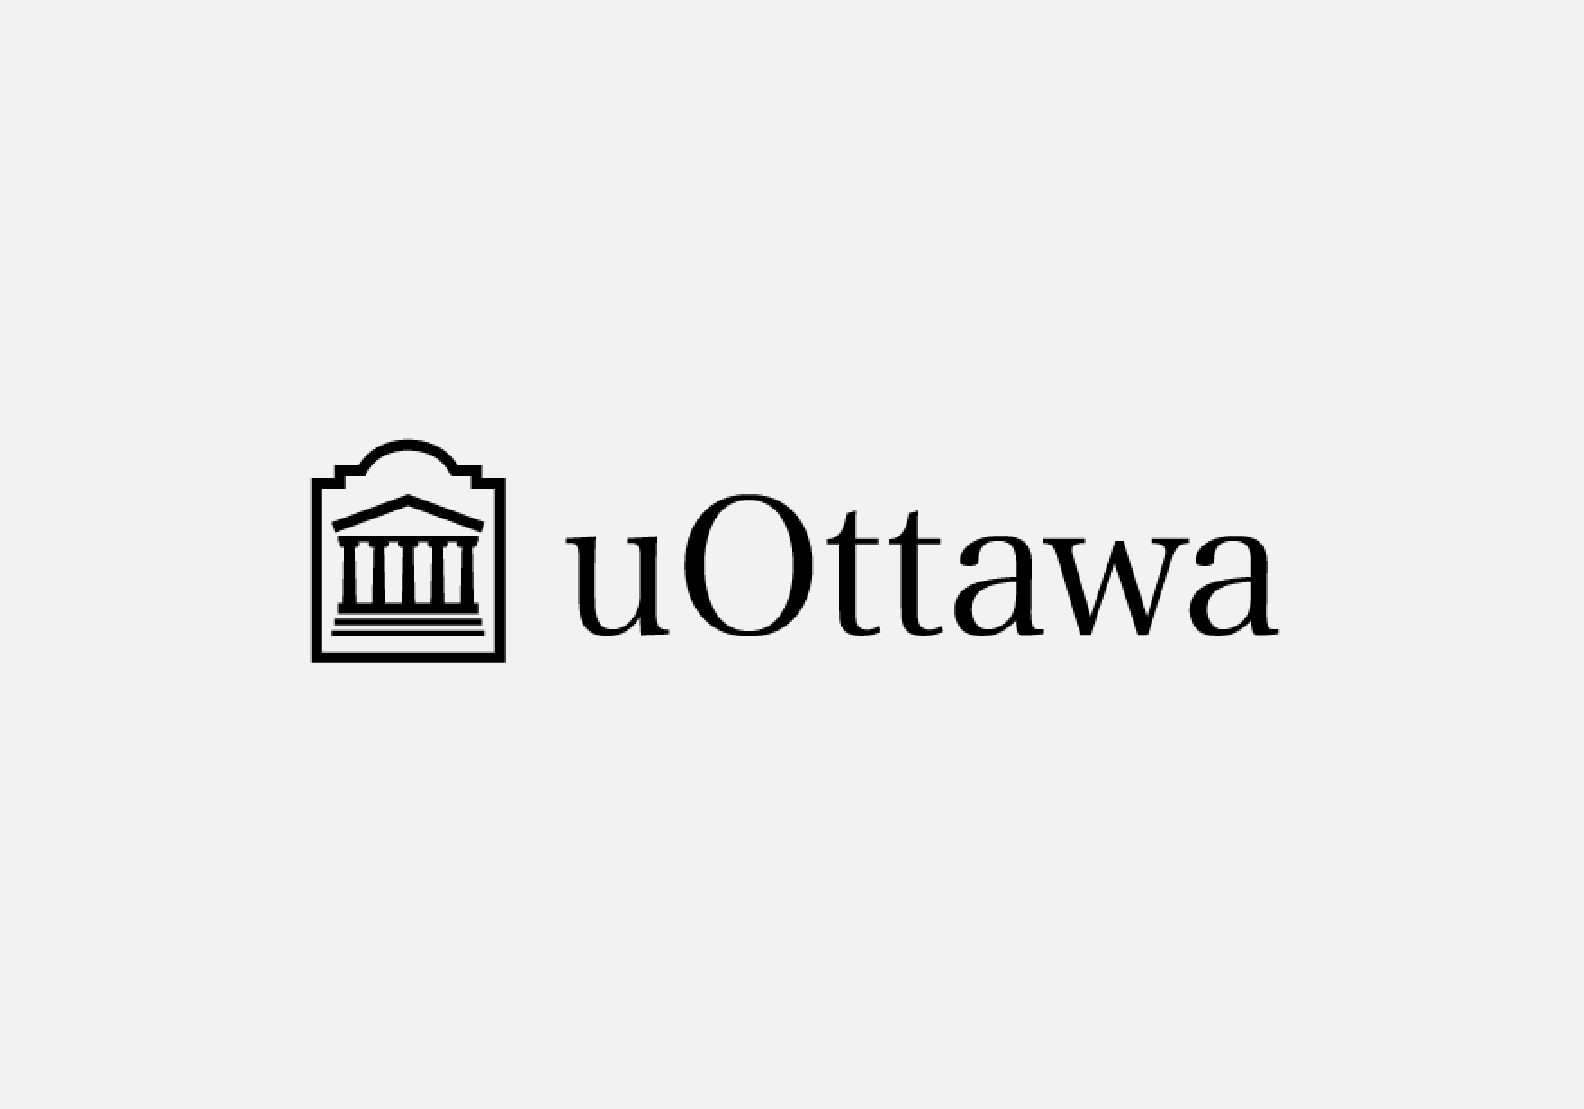
</div>

This notebook teaches how to ground API parsing code in evidence from the real response schema. The hydrology example uses the USGS NWIS Instantaneous Values service for streamflow parameter `00060`.

In [ ]:
# Browser package setup for JupyterLite. Safe to run in local Jupyter too.
import sys

if sys.platform == "emscripten":
    import piplite
    await piplite.install(["numpy", "pandas", "matplotlib", "scipy"])


## 1. Source Basis

The API and hydrological conventions are based on USGS and flow-duration references:

- USGS Water Services, Instantaneous Values Service documentation. https://waterservices.usgs.gov/docs/instantaneous-values/instantaneous-values-details/
- USGS Water Services documentation portal. https://waterservices.usgs.gov/
- USGS parameter-code reference for `00060`, discharge in cubic feet per second. https://help.waterdata.usgs.gov/code/parameter_cd_nm_query?fmt=html&parm_nm_cd=%25discharge%25
- Searcy, J. K. (1959). *Flow-duration curves*. U.S. Geological Survey Water-Supply Paper 1542-A. https://doi.org/10.3133/wsp1542A

Scientific note: this notebook uses a fixed response fixture so the lesson is reproducible. A live query should still inspect the returned schema, qualifiers, units, site metadata, and provisional-data status before analysis.

## 2. Learning Goal

For web APIs, the assistant should not guess the response schema. The safer workflow is:

1. Build the exact query URL.
2. Fetch or inspect a representative response.
3. Identify the nested path to the values and metadata.
4. Implement parsing against that observed schema.
5. Verify no-data handling, units, and hydrological calculations.

Hydrology target: parse instantaneous discharge from a NWIS JSON response, compute flow-duration thresholds, and flag high-flow events.

## 3. Libraries

The notebook uses standard Python tools. It does not make a live HTTP request during execution.

In [ ]:
from datetime import datetime
from urllib.parse import urlencode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

NWIS_IV_URL = "https://waterservices.usgs.gov/nwis/iv/"
STREAMFLOW_PARAMETER = "00060"

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 4. Query URL

The query asks for instantaneous discharge at USGS site `06610000`, Missouri River at Omaha, Nebraska. Parameter code `00060` represents discharge in cubic feet per second.

In [ ]:
def build_nwis_iv_url(site_id, start_date, end_date, parameter_code=STREAMFLOW_PARAMETER):
    query = urlencode({
        "sites": site_id,
        "parameterCd": parameter_code,
        "startDT": start_date,
        "endDT": end_date,
        "format": "json",
    })
    return f"{NWIS_IV_URL}?{query}"


example_url = build_nwis_iv_url("06610000", "2023-06-01", "2023-06-01")
example_url

## 5. Concept Graph

API-grounded coding means the parser follows evidence from the response, not memory of a schema.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.set_axis_off()

steps = [
    ('Query', 'Build exact URL'),
    ('Inspect', 'Read response schema'),
    ('Parse', 'Follow nested path'),
    ('Clean', 'Skip no-data values'),
    ('Verify', 'Test hydrology outputs'),
]

x = 0.12
width = 0.76
height = 0.105
if len(steps) == 1:
    y_positions = [0.50]
else:
    y_positions = [0.78 - i * (0.66 / (len(steps) - 1)) for i in range(len(steps))]

for i, ((step_title, subtitle), y) in enumerate(zip(steps, y_positions)):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#264653",
        facecolor="#edf6f9",
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(x + 0.035, y + height * 0.64, step_title, ha="left", va="center", fontsize=11, weight="bold", transform=ax.transAxes)
    ax.text(x + 0.035, y + height * 0.30, subtitle, ha="left", va="center", fontsize=9, transform=ax.transAxes)
    if i < len(steps) - 1:
        next_y = y_positions[i + 1]
        ax.annotate(
            "", xy=(0.50, next_y + height + 0.015), xytext=(0.50, y - 0.015),
            arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#264653"},
            xycoords=ax.transAxes,
        )

ax.set_title('API-Grounded Parser Workflow', pad=12)
plt.show()

## 6. Representative NWIS Response Fixture

The simplified fixture below preserves the important NWIS nesting: `value -> timeSeries -> values -> value`. The no-data sentinel is stored in `variable.noDataValue`.

In [ ]:
nwis_response = {
    "value": {
        "queryInfo": {
            "queryURL": example_url,
            "criteria": {"locationParam": "[ALL:06610000]", "variableParam": "[00060]"},
        },
        "timeSeries": [
            {
                "sourceInfo": {
                    "siteName": "Missouri River at Omaha, NE",
                    "siteCode": [{"value": "06610000", "network": "NWIS", "agencyCode": "USGS"}],
                },
                "variable": {
                    "variableCode": [{"value": "00060", "vocabulary": "NWIS:UnitValues"}],
                    "variableName": "Streamflow, ft3/s",
                    "variableDescription": "Discharge, cubic feet per second",
                    "unit": {"unitCode": "ft3/s"},
                    "noDataValue": -999999.0,
                },
                "values": [
                    {
                        "value": [
                            {"value": "12400", "qualifiers": ["P"], "dateTime": "2023-06-01T00:00:00.000-05:00"},
                            {"value": "12300", "qualifiers": ["P"], "dateTime": "2023-06-01T01:00:00.000-05:00"},
                            {"value": "12200", "qualifiers": ["P"], "dateTime": "2023-06-01T02:00:00.000-05:00"},
                            {"value": "-999999", "qualifiers": ["P"], "dateTime": "2023-06-01T03:00:00.000-05:00"},
                            {"value": "12100", "qualifiers": ["P"], "dateTime": "2023-06-01T04:00:00.000-05:00"},
                            {"value": "12000", "qualifiers": ["P"], "dateTime": "2023-06-01T05:00:00.000-05:00"},
                        ]
                    }
                ],
                "name": "USGS:06610000:00060:00000",
            }
        ],
    },
    "name": "ns1:timeSeriesResponseType",
}

nwis_response["value"]["timeSeries"][0]["sourceInfo"]["siteName"]

## 7. Schema Path

The parser should follow the exact path observed in the response.

In [ ]:
schema_paths = pd.DataFrame({
    "item": ["site name", "parameter code", "unit", "no-data sentinel", "measurements"],
    "json_path": [
        "value.timeSeries[0].sourceInfo.siteName",
        "value.timeSeries[0].variable.variableCode[0].value",
        "value.timeSeries[0].variable.unit.unitCode",
        "value.timeSeries[0].variable.noDataValue",
        "value.timeSeries[0].values[0].value",
    ],
})

schema_paths

## 8. Before and After Prompts

Weak prompt:

```text
Write code to get USGS streamflow data.
```

Grounded prompt:

```text
Before writing parsing code, inspect a representative NWIS IV JSON response for site 06610000 and parameter 00060.
Identify the exact path to time-series values, unit code, site name, and noDataValue.
Then implement the parser and verify that no-data sentinels are skipped, timestamps become datetimes, and flow-duration thresholds use the stated exceedance convention.
```

The second prompt asks for evidence before implementation.

## 9. Implementation

The fetching function is shown for completeness but is not executed in this notebook. The parser and hydrological calculations run against the local fixture.

In [ ]:
def fetch_usgs_streamflow(site_id, start_date, end_date):
    """Return the URL that should be fetched for NWIS instantaneous streamflow JSON."""
    return build_nwis_iv_url(site_id, start_date, end_date)


def parse_nwis_response(response):
    """Extract valid (datetime, discharge_cfs) records from a NWIS IV JSON response."""
    records = []
    for series in response.get("value", {}).get("timeSeries", []):
        no_data = float(series.get("variable", {}).get("noDataValue", -999999.0))
        for value_block in series.get("values", []):
            for item in value_block.get("value", []):
                flow = float(item["value"])
                if flow == no_data:
                    continue
                timestamp = datetime.fromisoformat(item["dateTime"])
                records.append((timestamp, flow))
    return sorted(records, key=lambda record: record[0])


def compute_flow_exceedance(flows, exceedance_pct):
    """Return the flow exceeded exceedance_pct percent of the time."""
    if not 0 <= exceedance_pct <= 100:
        raise ValueError("exceedance_pct must be between 0 and 100")
    values = np.asarray(flows, dtype=float)
    if values.size == 0:
        raise ValueError("flows must contain at least one value")
    return float(np.percentile(values, 100 - exceedance_pct))


def flag_flood_events(flows, threshold_cfs):
    """Flag timesteps where discharge strictly exceeds the threshold."""
    return [float(flow) > threshold_cfs for flow in flows]


parsed_records = parse_nwis_response(nwis_response)
parsed_records[:2]

## 10. Verification Tests

These checks verify the schema path, no-data handling, flow-duration convention, and event flagging.

In [ ]:
flows = [flow for _, flow in parsed_records]

assert fetch_usgs_streamflow("06610000", "2023-06-01", "2023-06-01").startswith(NWIS_IV_URL)
assert len(parsed_records) == 5
assert all(isinstance(timestamp, datetime) for timestamp, _ in parsed_records)
assert flows == [12400.0, 12300.0, 12200.0, 12100.0, 12000.0]

assert compute_flow_exceedance([10.0, 20.0, 30.0, 40.0, 50.0], 50) == 30.0
assert compute_flow_exceedance([10.0, 20.0, 30.0, 40.0, 50.0], 0) == 50.0
assert compute_flow_exceedance([10.0, 20.0, 30.0, 40.0, 50.0], 100) == 10.0
assert compute_flow_exceedance(list(range(1, 101)), 10) >= 90.0

assert flag_flood_events([100.0, 500.0, 200.0, 800.0], 400.0) == [False, True, False, True]
assert flag_flood_events([400.0], 400.0) == [False]

print("All NWIS parsing and hydrology checks passed.")

## 11. Parsed Streamflow Series

The parsed result is a clean time series of timestamped discharge values in cubic feet per second.

In [ ]:
flow_df = pd.DataFrame(parsed_records, columns=["datetime", "discharge_cfs"])
flow_df

In [ ]:
threshold_cfs = 12250.0
flow_df["above_threshold"] = flag_flood_events(flow_df["discharge_cfs"], threshold_cfs)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(flow_df["datetime"], flow_df["discharge_cfs"], marker="o", color="#0b7285", label="Parsed discharge")
ax.axhline(threshold_cfs, color="#d9480f", linestyle="--", label="Example threshold")
ax.set_title("Parsed NWIS Instantaneous Streamflow Fixture")
ax.set_xlabel("Datetime")
ax.set_ylabel("Discharge (ft3/s)")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.show()

In [ ]:
exceedance_summary = pd.DataFrame({
    "threshold": ["Q10", "Q50", "Q90"],
    "exceedance_probability_pct": [10, 50, 90],
    "discharge_cfs": [compute_flow_exceedance(flows, pct) for pct in [10, 50, 90]],
})

exceedance_summary

## 12. Hydrological Interpretation

The parser preserves the essential hydrological metadata: site, parameter, unit, timestamp, and no-data handling. The small fixture is not long enough for robust flow-duration or flood analysis, but it is useful for testing schema correctness. For real NWIS work, inspect qualifiers such as provisional status, confirm the parameter code and unit, and avoid interpreting short instantaneous windows as long-term flow statistics.

## 13. Summary

- API parsing code should be grounded in an observed response schema.
- NWIS instantaneous discharge values are nested under `value.timeSeries[].values[].value[]`.
- Parameter `00060` represents discharge in cubic feet per second for this workflow.
- No-data sentinels should be read from the response and skipped before analysis.
- Flow-duration and event-flag calculations are only meaningful after units, time step, qualifiers, and record length are checked.